# Effective Rank Analysis: The Geometry of Semantics

This notebook provides a powerful, quantitative representation learning diagnostic. We calculate the **Effective Rank ($r_{eff}$)** of our three models to mathematically prove how semantic information is structurally compressed or expanded.

We expect the progression to show:
$r_{eff}^{LSTM} < r_{eff}^{Model1} < r_{eff}^{Model2}$

In [6]:

import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

sys.path.append(os.path.abspath(r'C:\Users\Shrish\Desktop\semantic-comm\actual_project'))
from src.data_loader import EuroparlDataLoader
from src.tokenizer import SemanticTokenizer as LSTMTokenizer
from src.model import JointSemanticModel

sns.set_theme(style="whitegrid", palette="muted")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_dir = r"C:\Users\Shrish\Desktop\semantic-comm\Semantic_Communication\europarl\en\en"
loader = EuroparlDataLoader(data_dir=data_dir, target_sentences=1000)
loader.scan_and_load()
sentences = loader.all_sentences[:1000]
print(f"Successfully loaded {len(sentences)} sentences.")

def effective_rank(hidden_states):
    centered = hidden_states - hidden_states.mean(dim=0, keepdim=True)
    _, S, _ = torch.svd(centered)
    p = (S / S.sum()) + 1e-10
    entropy = -torch.sum(p * torch.log(p))
    return torch.exp(entropy).item(), S.cpu().numpy()

lstm_tokenizer = LSTMTokenizer()
lstm_tokenizer.fit(sentences)

lstm_model = JointSemanticModel(vocab_size=len(lstm_tokenizer.word2idx), embed_dim=128, hidden_dim=256, snr_db=10.0).to(device)
lstm_path = os.path.abspath(r"C:\Users\Shrish\Desktop\semantic-comm\actual_project\models\jscc_lstm.pt")
if os.path.exists(lstm_path):
    lstm_model.load_state_dict(torch.load(lstm_path, map_location=device))
lstm_model.eval()

lstm_states = []
with torch.no_grad():
    for sent in sentences[:200]: 
        tokens = torch.tensor([lstm_tokenizer.encode(sent)]).to(device)
        hidden, _ = lstm_model.encoder(tokens)
        lstm_states.append(hidden.squeeze(0))

lstm_h = torch.cat(lstm_states, dim=0)
erank_lstm, S_lstm = effective_rank(lstm_h)
print(f"LSTM Effective Rank: {erank_lstm:.2f} (out of {lstm_h.size(-1)} dims)")

Successfully loaded 983 sentences.
Scanning dataset to build vocabulary...
dictionary size: 3664
LSTM Effective Rank: 112.85 (out of 256 dims)


In [7]:
#mode1 analysis (channel unaware)
from transformers import T5Tokenizer
from src.llm_model import GenerativeSemanticModel

t5_tokenizer = T5Tokenizer.from_pretrained("t5-small", local_files_only=True)
model1 = GenerativeSemanticModel(model_name="t5-small", snr_db=5.0).to(device)

m1_path = os.path.abspath(r"C:\Users\Shrish\Desktop\semantic-comm\actual_project\models\t5_semantic.pt")
if os.path.exists(m1_path):
    model1.load_state_dict(torch.load(m1_path, map_location=device, weights_only=True))
model1.eval()

m1_states = []
with torch.no_grad():
    for sent in sentences[:200]:
        inputs = t5_tokenizer(sent, return_tensors="pt", max_length=20, padding="max_length", truncation=True).to(device)
        enc_out = model1.t5.encoder(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"], return_dict=True)
        m1_states.append(enc_out.last_hidden_state.squeeze(0))

m1_h = torch.cat(m1_states, dim=0)
erank_m1, S_m1 = effective_rank(m1_h)
print(f"M1-channel unaware Effective Rank: {erank_m1:.2f} (out of {m1_h.size(-1)} dims)")

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

M1-channel unaware Effective Rank: 372.11 (out of 512 dims)


In [8]:
#mode2 analysis , (channel aware waala)
from src.llm_model_2 import AdvancedGenerativeSemanticModel


model2 = AdvancedGenerativeSemanticModel(model_name="t5-small", snr_db=5.0).to(device)

m2_path = os.path.abspath(r"C:\Users\Shrish\Desktop\semantic-comm\actual_project\models\t5_semantic_advanced.pt")
model2_exists = os.path.exists(m2_path)
if model2_exists:
    model2.load_state_dict(torch.load(m2_path, map_location=device, weights_only=True))
model2.eval()

m2_states = []
with torch.no_grad():
    for sent in sentences[:200]:
        inputs = t5_tokenizer(sent, return_tensors="pt", max_length=20, padding="max_length", truncation=True).to(device)
        enc_out = model2.t5.encoder(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"], return_dict=True)
        pristine = enc_out.last_hidden_state.squeeze(0)
        
        #adaptive snr embed layer 
        snr_tensor = model2._get_snr_tensor(1, device, 5.0)
        snr_emb = model2.snr_embed(snr_tensor).squeeze(0)
        adapted = pristine + snr_emb
        m2_states.append(adapted)

m2_h = torch.cat(m2_states, dim=0)
erank_m2, S_m2 = effective_rank(m2_h)
print(f"M2-channel aware Effective Rank: {erank_m2:.2f} (out of {m2_h.size(-1)} dims)")

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

M2-channel aware Effective Rank: 408.54 (out of 512 dims)


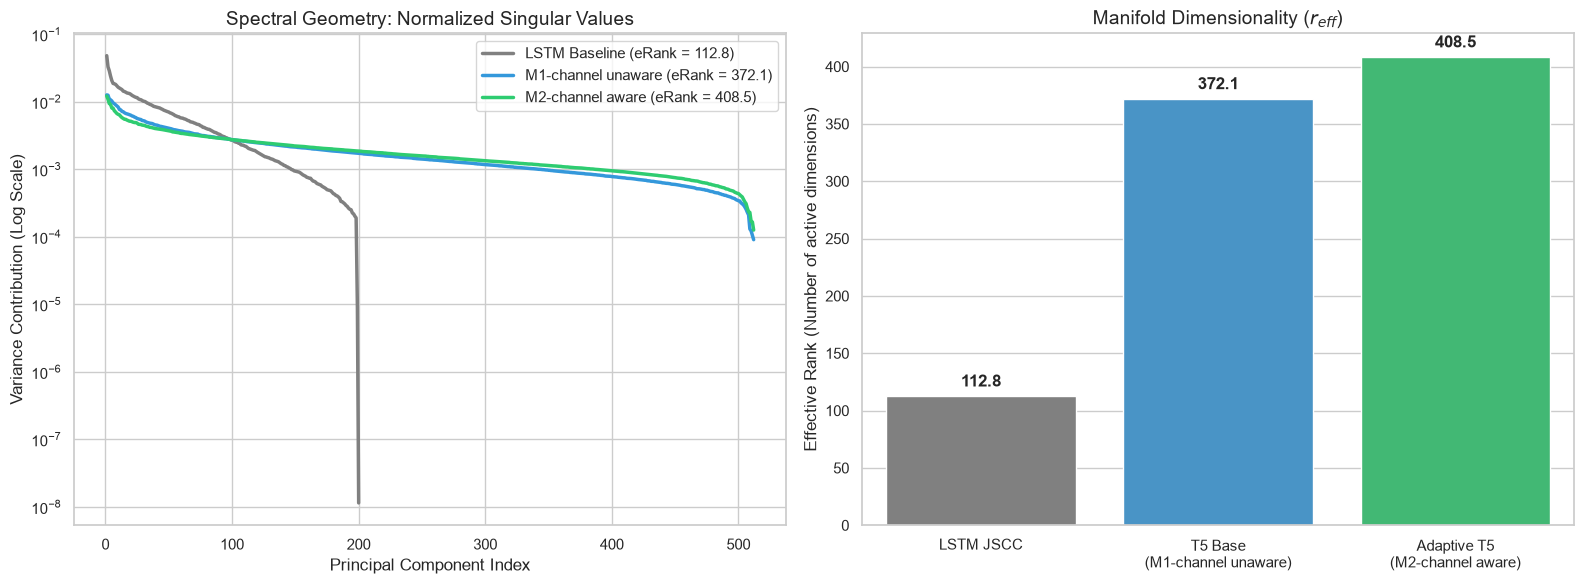

LSTM -> M1-channel unaware -> M2-channel aware corresponds to a progression from:

  1. Sequential Semantic Compression (eRank ~ 112.8)
  2. Global Semantic Representation (eRank ~ 372.1)
  3. Channel-Aware Adaptive Semantic Geometry (eRank ~ 408.5)


In [9]:
# graphs

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


axes[0].plot(range(1, len(S_lstm)+1), S_lstm / S_lstm.sum(), color='gray', lw=2.5, 
         label=f'LSTM Baseline (eRank = {erank_lstm:.1f})')
axes[0].plot(range(1, len(S_m1)+1), S_m1 / S_m1.sum(), color='#3498db', lw=2.5, 
         label=f'M1-channel unaware (eRank = {erank_m1:.1f})')
axes[0].plot(range(1, len(S_m2)+1), S_m2 / S_m2.sum(), color='#2ecc71', lw=2.5, 
         label=f'M2-channel aware (eRank = {erank_m2:.1f})')

axes[0].set_yscale('log')
axes[0].set_title("Spectral Geometry: Normalized Singular Values", fontsize=14)
axes[0].set_xlabel("Principal Component Index")
axes[0].set_ylabel("Variance Contribution (Log Scale)")
axes[0].legend()

models = ['LSTM JSCC', 'T5 Base\n(M1-channel unaware)', 'Adaptive T5\n(M2-channel aware)']
ranks = [erank_lstm, erank_m1, erank_m2]
sns.barplot(x=models, y=ranks, palette=['gray', '#3498db', '#2ecc71'], ax=axes[1])
axes[1].set_title("Manifold Dimensionality ($r_{eff}$)", fontsize=14)
axes[1].set_ylabel("Effective Rank (Number of active dimensions)")

for i, r in enumerate(ranks):
    axes[1].text(i, r + (max(ranks)*0.02), f"{r:.1f}", ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()


print(f"LSTM -> M1-channel unaware -> M2-channel aware corresponds to a progression from:")
print(f"\n  1. Sequential Semantic Compression (eRank ~ {erank_lstm:.1f})")
print(f"  2. Global Semantic Representation (eRank ~ {erank_m1:.1f})")
print(f"  3. Channel-Aware Adaptive Semantic Geometry (eRank ~ {erank_m2:.1f})")
